In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spamvsham.csv to spamvsham.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [ ]:
# Load dataset
df = pd.read_csv('spamvsham.csv', encoding='latin-1')

# Keep only useful columns
df = df[['v1', 'v2']].copy()
df.columns = ['label', 'message']

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Class distribution
print("Class Distribution:")
print(df['label'].value_counts())
print("\nPercentages:")
print(df['label'].value_counts(normalize=True).mul(100).round(2))

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [ ]:
# Message length analysis
df['char_count'] = df['message'].str.len()
df['word_count'] = df['message'].str.split().str.len()

print("=== Message Length Stats ===")
print(df.groupby('label')[['char_count','word_count']].mean().round(1))
print("\nOverall:")
print(df[['char_count','word_count']].describe().round(1))

=== Message Length Stats ===
       char_count  word_count
label                        
ham          71.0        14.2
spam        138.9        23.9

Overall:
       char_count  word_count
count      5572.0      5572.0
mean         80.1        15.5
std          59.7        11.3
min           2.0         1.0
25%          36.0         7.0
50%          61.0        12.0
75%         121.0        23.0
max         910.0       171.0


In [ ]:
# Check for duplicates and nulls
print("Null values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Null values:
 label         0
message       0
char_count    0
word_count    0
dtype: int64

Duplicate rows: 403


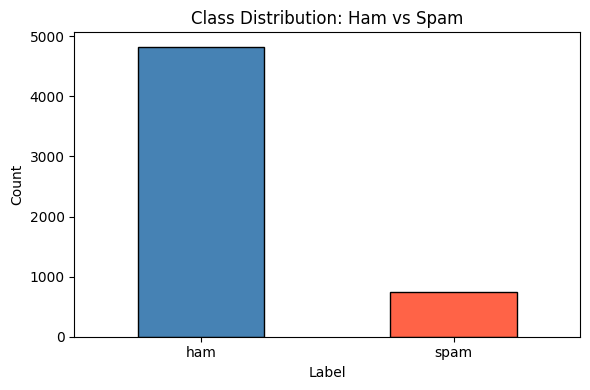

In [ ]:
# 1. Class Distribution Bar Chart
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('Class Distribution: Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

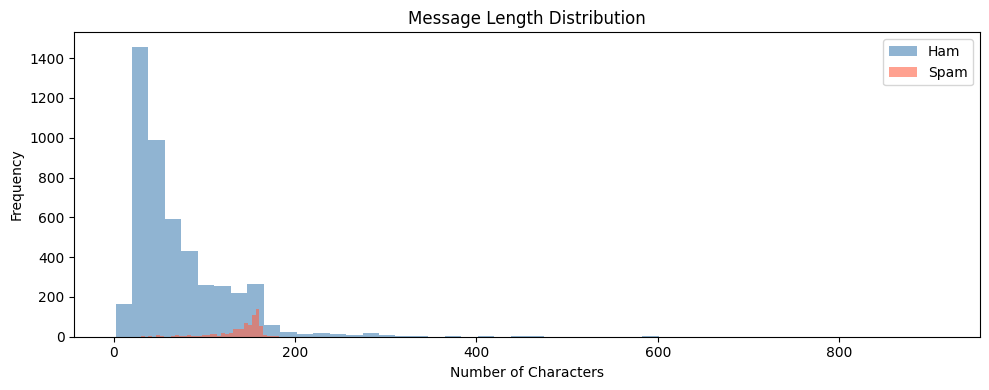

In [ ]:
# 2. Message Length Distribution
plt.figure(figsize=(10,4))
df[df['label']=='ham']['char_count'].plot(kind='hist', bins=50, alpha=0.6, color='steelblue', label='Ham')
df[df['label']=='spam']['char_count'].plot(kind='hist', bins=50, alpha=0.6, color='tomato', label='Spam')
plt.title('Message Length Distribution')
plt.xlabel('Number of Characters')
plt.legend()
plt.tight_layout()
plt.savefig('message_length.png', dpi=150)
plt.show()

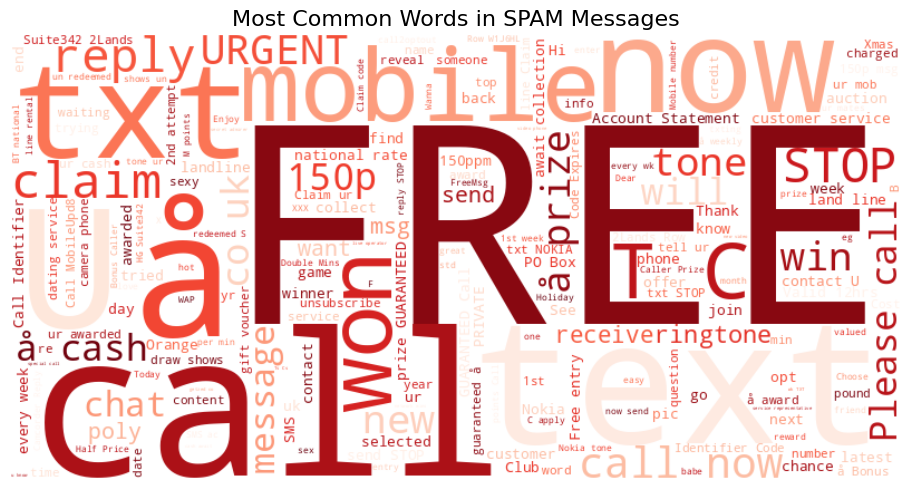

In [ ]:
# 3. Word Cloud - Spam
spam_text = ' '.join(df[df['label']=='spam']['message'].tolist())
wc_spam = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds').generate(spam_text)
plt.figure(figsize=(10,5))
plt.imshow(wc_spam, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in SPAM Messages', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_spam.png', dpi=150)
plt.show()

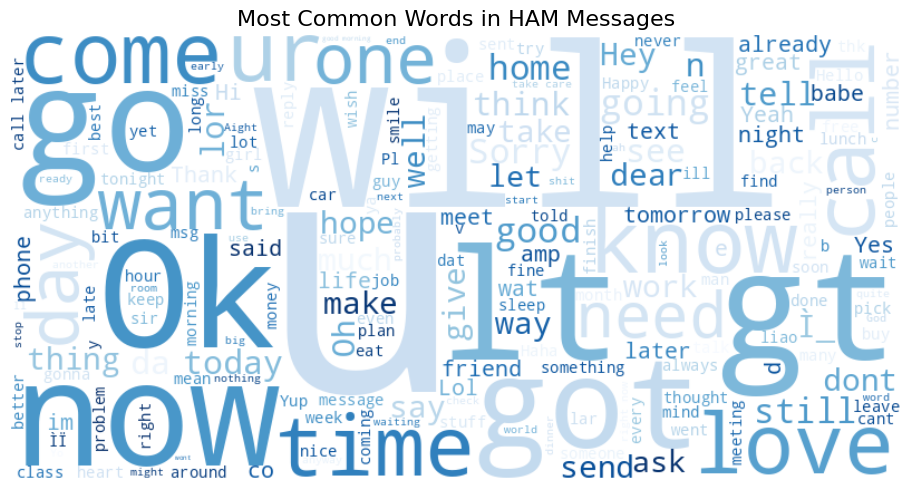

In [ ]:
# 4. Word Cloud - Ham
ham_text = ' '.join(df[df['label']=='ham']['message'].tolist())
wc_ham = WordCloud(width=800, height=400, background_color='white',
                   colormap='Blues').generate(ham_text)
plt.figure(figsize=(10,5))
plt.imshow(wc_ham, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in HAM Messages', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_ham.png', dpi=150)
plt.show()

In [ ]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = text.split()                        # tokenize
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]  # remove stopwords + stem
    return ' '.join(tokens)

# Remove duplicates first
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df)} messages")

# Apply preprocessing
df['clean_message'] = df['message'].apply(preprocess)
print("Preprocessing done!")
df[['message','clean_message']].head(3)

After removing duplicates: 5169 messages
Preprocessing done!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...


In [ ]:
# Encode labels
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['clean_message']
y = df['label_encoded']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training size: {X_train_tfidf.shape}")
print(f"Testing size:  {X_test_tfidf.shape}")

Training size: (4135, 5000)
Testing size:  (1034, 5000)


In [ ]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': LinearSVC()
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred)*100, 2),
        'Precision': round(precision_score(y_test, y_pred)*100, 2),
        'Recall':    round(recall_score(y_test, y_pred)*100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred)*100, 2)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision  Recall  F1-Score
Naive Bayes             96.62      98.98   74.05     84.72
Logistic Regression     96.03     100.00   68.70     81.45
SVM                     97.97      97.41   86.26     91.50


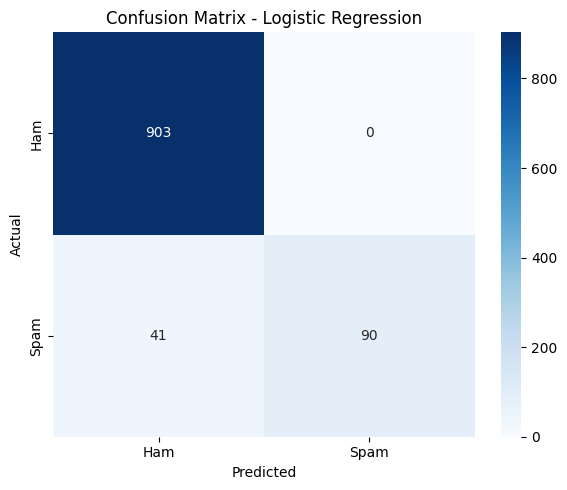


Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.69      0.81       131

    accuracy                           0.96      1034
   macro avg       0.98      0.84      0.90      1034
weighted avg       0.96      0.96      0.96      1034



In [ ]:
# Use Logistic Regression (usually best performer)
best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham','Spam']))

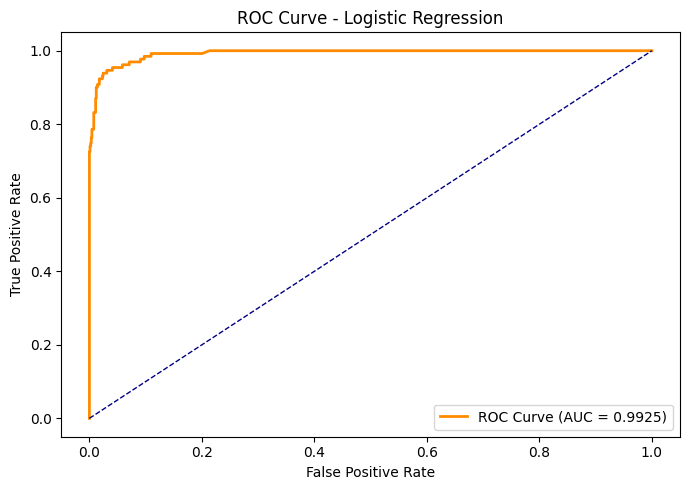

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_proba = lr_model.predict_proba(X_test_tfidf)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [ ]:
def predict_message(msg):
    cleaned = preprocess(msg)
    vec = tfidf.transform([cleaned])
    pred = best_model.predict(vec)[0]
    label = "SPAM" if pred == 1 else "HAM"
    print(f"Message: {msg}")
    print(f"Prediction: {label}")

predict_message("Congratulations! You won a free prize, call now!")
predict_message("Hey, are you coming to class tomorrow?")

Message: Congratulations! You won a free prize, call now!
Prediction: SPAM
Message: Hey, are you coming to class tomorrow?
Prediction: HAM
